In [7]:
import pandas as pd
df = pd.read_excel(r"C:\Users\admin\Downloads\startup_prediction_adjusted.xlsx", engine="openpyxl")
print("Dataset loaded successfully!")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
print(df.head())

Dataset loaded successfully!
Rows: 100000
Columns: 15
     startup_name  startup_age  funding_rounds  founder_experience_years  \
0  Startup_000001            2               4                        13   
1  Startup_000002           12               1                         6   
2  Startup_000003           10               3                         5   
3  Startup_000004            7               3                        14   
4  Startup_000005            7               1                        17   

   team_size  market_size_billion  product_traction_users  burn_rate_million  \
0         58            48.225483                  594843          18.519211   
1        221            31.532647                  393020          14.298149   
2        247             4.969722                   27636          20.447567   
3        229             3.084209                  235376           8.177417   
4        235            13.818188                  391765           4.879792   

   reven

In [8]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['startup_name', 'startup_age', 'funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million', 'investor_type', 'sector', 'founder_background', 'outcome', 'Potential_Level', 'Success']


In [9]:
print("Missing values in each columns:")
print(df.isnull().sum())

Missing values in each columns:
startup_name                0
startup_age                 0
funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
Potential_Level             0
Success                     0
dtype: int64


In [10]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [11]:
print("Success value counts:")
print(df["Success"].value_counts())

Success value counts:
Success
0    55610
1    44390
Name: count, dtype: int64


In [12]:
print("Summary of Numerical data:")
display(df.describe())

Summary of Numerical data:


,startup_age,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,Success
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000
mean,7.998500,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05,0.443900
std,4.319061,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05,0.496845
min,1.000000,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03,0.000000
25%,4.000000,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05,0.000000
50%,8.000000,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05,0.000000
75%,12.000000,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06,1.000000
max,15.000000,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06,1.000000


In [13]:
categorical_cols = [ "investor_type", "sector", "founder_background" ] 
for col in categorical_cols: 
    print("\n", col) 
    print(df[col].value_counts())


 investor_type
investor_type
tier2_vc    35327
angel       25137
none        24866
tier1_vc    14670
Name: count, dtype: int64

 sector
sector
Crypto       14456
Climate      14412
Health       14357
SaaS         14333
Fintech      14220
Ecommerce    14148
AI           14074
Name: count, dtype: int64

 founder_background
founder_background
first_time        39980
ex_bigtech        25009
academic          20054
serial_founder    14957
Name: count, dtype: int64


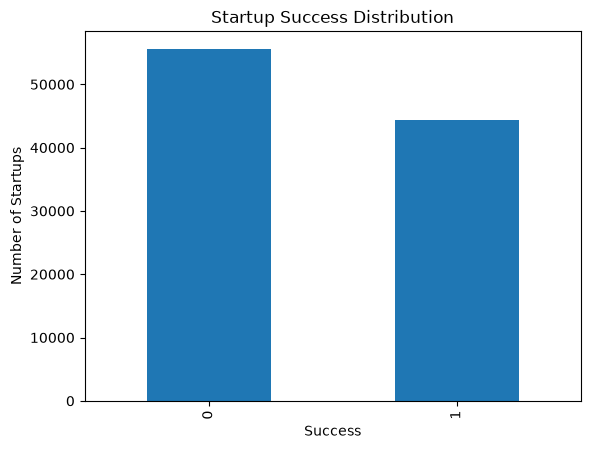

In [14]:
import matplotlib.pyplot as plt

df["Success"].value_counts().plot(kind="bar")

plt.title("Startup Success Distribution")
plt.xlabel("Success")
plt.ylabel("Number of Startups")
plt.show()


In [7]:
import pandas as pd
df = pd.read_excel(r"C:\Users\admin\Downloads\startup_prediction_adjusted.xlsx", engine="openpyxl")
success_by_sector = pd.crosstab(df["sector"], df["Success"], normalize="index") * 100

print("Success percentage by sector:")
display(success_by_sector.round(2))

Success percentage by sector:


Success,0,1
sector,,
AI,55.86,44.14
Climate,55.54,44.46
Crypto,55.10,44.90
Ecommerce,55.58,44.42
Fintech,56.32,43.68
Health,55.16,44.84
SaaS,55.73,44.27


In [8]:
print("Success rate by investor type:")
print(pd.crosstab(df["investor_type"], df["Success"], normalize="index").round(2) * 100)

Success rate by investor type:
Success           0     1
investor_type            
angel          56.0  44.0
none           55.0  45.0
tier1_vc       56.0  44.0
tier2_vc       56.0  44.0


In [9]:
print("Success rate by founder background:")

success_by_background = pd.crosstab(df["founder_background"], df["Success"], normalize="index") * 100

display(success_by_background.round(2))

Success rate by founder background:


Success,0,1
founder_background,,
academic,56.19,43.81
ex_bigtech,55.75,44.25
first_time,55.39,44.61
serial_founder,55.18,44.82


In [10]:
numerical_cols = ["startup_age","funding_rounds","founder_experience_years","team_size","market_size_billion","product_traction_users","burn_rate_million","revenue_million"]

print("Average values by Success:")
display(df.groupby("Success")[numerical_cols].mean().round(2))

Average values by Success:


,startup_age,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
Success,,,,,,,,
0,8.0,1.70,10.75,143.46,33.08,225905.48,16.72,536378.93
1,8.0,2.38,13.63,159.84,33.35,359983.77,16.85,1091549.49


In [11]:
correlation = df[numerical_cols + ["Success"]].corr()

print("Correlation with Success:")
display(correlation["Success"].sort_values(ascending=False).round(2))

Correlation with Success:


Success                     1.00
revenue_million             0.45
product_traction_users      0.42
funding_rounds              0.24
founder_experience_years    0.20
team_size                   0.09
burn_rate_million           0.00
market_size_billion         0.00
startup_age                -0.00
Name: Success, dtype: float64

# EDA Findings

## Dataset Overview

The dataset contains 100,000 startup records and 15 columns. There are no missing values and no duplicate rows.

## Target Variable

The target variable is `Success`, which contains two classes:
- 0: Unsuccessful startup
- 1: Successful startup

The dataset contains 55,610 unsuccessful startups and 44,390 successful startups.

## Feature Analysis

The numerical and categorical features were explored to understand their relationship with startup success.

The analysis included:
- Success distribution
- Investor type
- Founder background
- Numerical feature averages
- Correlation with the Success variable

## Data Quality

The dataset has no missing values or duplicate rows, making it suitable for further analysis and machine-learning preparation.

## Target Leakage

The columns `outcome` and `Potential_Level` should not be used as model input features because they provide information directly related to the `Success` target.

## Conclusion

The exploratory data analysis provides an initial understanding of the dataset and identifies useful features for further machine-learning research. The final feature selection and predictive model should be handled by Member 4.